In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, RFE
from collections import Counter
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor, SGDRegressor, QuantileRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error


In [83]:
data_df = pd.read_csv("../processed_data/data_combined_training.csv", index_col=0)
data_df = data_df.dropna().reset_index(drop=True)
data_df 

,App A,App B,Num Nodes,App A Isolated Time,App B Isolated Time,App A Co-Scheduled Time with App B,App B Co-Scheduled Time with App A,App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d],...,App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=10000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=10000us_Sparsity=1.0_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=1.0_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d]
0,beatnik,fiesta,8,397.734375,359.091518,401.447545,356.144531,425.018415,367.84096,406.275670,...,669.295759,357.435826,557.663504,362.359375,661.912388,359.669085,484.195312,359.164062,634.975446,368.329241
1,beatnik,lammps,8,397.734375,354.750000,403.132812,359.000000,425.018415,361.50000,406.275670,...,669.295759,369.250000,557.663504,371.750000,661.912388,366.750000,484.195312,359.750000,634.975446,364.250000
2,beatnik,minife,8,397.734375,388.250000,407.513951,391.000000,425.018415,398.50000,406.275670,...,669.295759,426.531250,557.663504,417.750000,661.912388,407.250000,484.195312,400.750000,634.975446,409.250000
3,beatnik,minivite,8,397.734375,371.250000,405.080915,377.500000,425.018415,388.25000,406.275670,...,669.295759,450.084263,557.663504,442.250000,661.912388,445.750000,484.195312,408.750000,634.975446,446.500000
4,beatnik,tricount,8,397.734375,378.000000,446.388951,395.000000,425.018415,436.50000,406.275670,...,669.295759,619.250000,557.663504,531.500000,661.912388,603.750000,484.195312,507.000000,634.975446,619.000000
5,fiesta,lammps,8,359.091518,354.750000,356.097656,359.750000,367.840960,361.50000,356.541853,...,357.435826,369.250000,362.359375,371.750000,359.669085,366.750000,359.164062,359.750000,368.329241,364.250000
6,fiesta,minife,8,359.091518,388.250000,356.042969,388.750000,367.840960,398.50000,356.541853,...,357.435826,426.531250,362.359375,417.750000,359.669085,407.250000,359.164062,400.750000,368.329241,409.250000
7,fiesta,minivite,8,359.091518,371.250000,356.143415,374.250000,367.840960,388.25000,356.541853,...,357.435826,450.084263,362.359375,442.250000,359.669085,445.750000,359.164062,408.750000,368.329241,446.500000
8,fiesta,tricount,8,359.091518,378.000000,356.861607,383.000000,367.840960,436.50000,356.541853,...,357.435826,619.250000,362.359375,531.500000,359.669085,603.750000,359.164062,507.000000,368.329241,619.000000
9,lammps,minife,8,354.750000,388.250000,352.250000,388.000000,361.500000,398.50000,354.000000,...,369.250000,426.531250,371.750000,417.750000,366.750000,407.250000,359.750000,400.750000,364.250000,409.250000


In [84]:
print(list(data_df.columns))

['App A', 'App B', 'Num Nodes', 'App A Isolated Time', 'App B Isolated Time', 'App A Co-Scheduled Time with App B', 'App B Co-Scheduled Time with App A', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=1000us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=1000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with In

In [85]:
# Double the dataset size by splitting App A and App B targets into two rows
# Identify column categories
app_a_isolated = 'App A Isolated Time'
app_b_isolated = 'App B Isolated Time'

inhib_a_cols = [c for c in data_df.columns if c.startswith('App A Co-Scheduled Time with Inhib')]
inhib_b_cols = [c for c in data_df.columns if c.startswith('App B Co-Scheduled Time with Inhib')]

cosched_a_col = 'App A Co-Scheduled Time with App B'
cosched_b_col = 'App B Co-Scheduled Time with App A'

# --- Row type 1: original row, drop "App B Co-Scheduled Time with App A" ---
data_df_type1 = data_df.drop(columns=[cosched_b_col]).copy()

# --- Row type 2: swap App A <-> App B, keep only "App A Co-Scheduled Time with App B" (post-swap) ---
data_df_type2 = data_df.copy()

# Swap App A / App B names
data_df_type2['App A'] = data_df['App B']
data_df_type2['App B'] = data_df['App A']

# Swap isolated times
data_df_type2[app_a_isolated] = data_df[app_b_isolated]
data_df_type2[app_b_isolated] = data_df[app_a_isolated]

# Swap inhibitor columns pairwise
# inhib_a_cols[i] pairs with inhib_b_cols[i] (same param suffix)
for col_a, col_b in zip(inhib_a_cols, inhib_b_cols):
    data_df_type2[col_a] = data_df[col_b]
    data_df_type2[col_b] = data_df[col_a]

# After swap, "App A Co-Scheduled Time with App B" should hold what was cosched_b_col
data_df_type2[cosched_a_col] = data_df[cosched_b_col]

# Drop the cosched_b column (only keep cosched_a)
data_df_type2 = data_df_type2.drop(columns=[cosched_b_col])

# --- Combine ---
data_df_extended = pd.concat([data_df_type1, data_df_type2], ignore_index=True)
data_df_extended

,App A,App B,Num Nodes,App A Isolated Time,App B Isolated Time,App A Co-Scheduled Time with App B,App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d],...,App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=10000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=10000us_Sparsity=1.0_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=100000us_Sparsity=1.0_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d],App A Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App B Co-Scheduled Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d]
0,beatnik,fiesta,8,397.734375,359.091518,401.447545,425.018415,367.840960,406.275670,356.541853,...,669.295759,357.435826,557.663504,362.359375,661.912388,359.669085,484.195312,359.164062,634.975446,368.329241
1,beatnik,lammps,8,397.734375,354.750000,403.132812,425.018415,361.500000,406.275670,354.000000,...,669.295759,369.250000,557.663504,371.750000,661.912388,366.750000,484.195312,359.750000,634.975446,364.250000
2,beatnik,minife,8,397.734375,388.250000,407.513951,425.018415,398.500000,406.275670,390.250000,...,669.295759,426.531250,557.663504,417.750000,661.912388,407.250000,484.195312,400.750000,634.975446,409.250000
3,beatnik,minivite,8,397.734375,371.250000,405.080915,425.018415,388.250000,406.275670,379.750000,...,669.295759,450.084263,557.663504,442.250000,661.912388,445.750000,484.195312,408.750000,634.975446,446.500000
4,beatnik,tricount,8,397.734375,378.000000,446.388951,425.018415,436.500000,406.275670,433.250000,...,669.295759,619.250000,557.663504,531.500000,661.912388,603.750000,484.195312,507.000000,634.975446,619.000000
5,fiesta,lammps,8,359.091518,354.750000,356.097656,367.840960,361.500000,356.541853,354.000000,...,357.435826,369.250000,362.359375,371.750000,359.669085,366.750000,359.164062,359.750000,368.329241,364.250000
6,fiesta,minife,8,359.091518,388.250000,356.042969,367.840960,398.500000,356.541853,390.250000,...,357.435826,426.531250,362.359375,417.750000,359.669085,407.250000,359.164062,400.750000,368.329241,409.250000
7,fiesta,minivite,8,359.091518,371.250000,356.143415,367.840960,388.250000,356.541853,379.750000,...,357.435826,450.084263,362.359375,442.250000,359.669085,445.750000,359.164062,408.750000,368.329241,446.500000
8,fiesta,tricount,8,359.091518,378.000000,356.861607,367.840960,436.500000,356.541853,433.250000,...,357.435826,619.250000,362.359375,531.500000,359.669085,603.750000,359.164062,507.000000,368.329241,619.000000
9,lammps,minife,8,354.750000,388.250000,352.250000,361.500000,398.500000,354.000000,390.250000,...,369.250000,426.531250,371.750000,417.750000,366.750000,407.250000,359.750000,400.750000,364.250000,409.250000


In [86]:
"""
Feature Selection Script for Co-Scheduled App Timing Data
==========================================================
Target: "App A Co-Scheduled Time with App B"
Preserved (untouched): "App A", "App B"
All other columns: features (normalized before selection)

Techniques used:
  1. Pearson Correlation
  2. Mutual Information Regression
  3. Random Forest Feature Importance
  4. Lasso (L1 Regularization)
  5. Recursive Feature Elimination (RFE) with Ridge

Consensus: features selected by ALL (or most) methods are reported.
"""


# ── CONFIG ────────────────────────────────────────────────────────────────────
TARGET_COL = "App A Co-Scheduled Time with App B"
PRESERVE_COLS = ["App A", "App B"]    # kept intact, excluded from scaling/selection
K = 8                               # number of top features to select per method
RANDOM_STATE = 42
# ─────────────────────────────────────────────────────────────────────────────


def split_columns(df: pd.DataFrame):
    """Separate preserved, target, and feature columns."""
    feature_cols = [
        c for c in df.columns
        if c not in PRESERVE_COLS + [TARGET_COL]
    ]
    print(f"  Preserved columns : {PRESERVE_COLS}")
    print(f"  Target column     : {TARGET_COL}")
    print(f"  Feature columns   : {len(feature_cols)}")
    return feature_cols


def normalize_features(df: pd.DataFrame, feature_cols: list) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Standardize (zero mean, unit variance) only the feature columns.
    Returns the scaler-transformed X array, the raw y array, and feature col list.
    """
    X_raw = df[feature_cols].values
    y = df[TARGET_COL].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    print(f"\nStandardization complete (StandardScaler).")
    print(f"  X shape: {X_scaled.shape}, y shape: {y.shape}")
    return X_scaled, y


# ── FEATURE SELECTION METHODS ─────────────────────────────────────────────────

def select_by_correlation(df: pd.DataFrame, feature_cols: list, k: int) -> list:
    """Pearson correlation between each feature and the target."""
    print("\n[1] Pearson Correlation ...")
    corr = df[feature_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
    top = corr.abs().nlargest(k).index.tolist()
    print(f"    Top {k}: {top}")
    return top


def select_by_mutual_info(X: np.ndarray, y: np.ndarray, feature_cols: list, k: int) -> list:
    """Mutual information regression (model-free, captures non-linear relationships)."""
    print("\n[2] Mutual Information Regression ...")
    mi_scores = mutual_info_regression(X, y, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=feature_cols)
    top = mi_series.nlargest(k).index.tolist()
    print(f"    Top {k}: {top}")
    return top


def select_by_random_forest(X: np.ndarray, y: np.ndarray, feature_cols: list, k: int) -> list:
    """Random Forest feature importances (mean decrease in impurity)."""
    print("\n[3] Random Forest Feature Importance ...")
    rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    rf_series = pd.Series(rf.feature_importances_, index=feature_cols)
    top = rf_series.nlargest(k).index.tolist()
    print(f"    Top {k}: {top}")
    return top


def select_by_lasso(X: np.ndarray, y: np.ndarray, feature_cols: list, k: int) -> list:
    """
    Lasso (L1) regression: drives irrelevant feature coefficients to zero.
    Alpha is tuned to retain approximately k features.
    """
    print("\n[4] Lasso (L1 Regularization) ...")

    # Try a range of alphas; pick the one closest to retaining k non-zero features
    best_alpha = None
    best_top = []
    best_diff = float("inf")

    for alpha in np.logspace(-4, 1, 60):
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE)
        lasso.fit(X, y)
        nonzero = np.sum(lasso.coef_ != 0)
        diff = abs(nonzero - k)
        if diff < best_diff:
            best_diff = diff
            best_alpha = alpha
            coef_series = pd.Series(np.abs(lasso.coef_), index=feature_cols)
            best_top = coef_series[coef_series > 0].nlargest(k).index.tolist()

    print(f"    Best alpha: {best_alpha:.6f}  (non-zero features ≈ {len(best_top)})")
    print(f"    Top {k}: {best_top}")
    return best_top


def select_by_rfe(X: np.ndarray, y: np.ndarray, feature_cols: list, k: int) -> list:
    """Recursive Feature Elimination using Ridge as the estimator."""
    print("\n[5] Recursive Feature Elimination (RFE with Ridge) ...")
    ridge = Ridge()
    rfe = RFE(estimator=ridge, n_features_to_select=k)
    rfe.fit(X, y)
    top = [feature_cols[i] for i, s in enumerate(rfe.support_) if s]
    print(f"    Top {k}: {top}")
    return top


# ── CONSENSUS ─────────────────────────────────────────────────────────────────

def compute_consensus(all_selections: dict, feature_cols: list) -> pd.DataFrame:
    """
    Count how many methods selected each feature.
    Print features chosen by ALL methods first, then by majority, etc.
    """
    print("\n" + "=" * 60)
    print("CONSENSUS RESULTS")
    print("=" * 60)

    counter = Counter()
    for method, features in all_selections.items():
        counter.update(features)

    consensus_df = pd.DataFrame(
        counter.most_common(),
        columns=["Feature", "Methods_Count"]
    )
    consensus_df["Methods"] = consensus_df["Feature"].apply(
        lambda f: [m for m, feats in all_selections.items() if f in feats]
    )

    n_methods = len(all_selections)

    unanimous = consensus_df[consensus_df["Methods_Count"] == n_methods]
    print(f"\n Features selected by ALL {n_methods} methods ({len(unanimous)} features):")
    if unanimous.empty:
        print("   (none — consider lowering k or the consensus threshold)")
    else:
        for _, row in unanimous.iterrows():
            print(f"   • {row['Feature']}")

    majority = consensus_df[
        (consensus_df["Methods_Count"] >= n_methods / 2) &
        (consensus_df["Methods_Count"] < n_methods)
    ]
    print(f"\n Features selected by MAJORITY (≥{n_methods//2 + 1}) but not all ({len(majority)} features):")
    for _, row in majority.iterrows():
        print(f"   • {row['Feature']}  (picked by {row['Methods_Count']}/{n_methods}: {row['Methods']})")

    print("\n Full ranked consensus table:")
    print(consensus_df[["Feature", "Methods_Count"]].to_string(index=False))

    return consensus_df

# 1. Use the existing dataframe directly
df = data_df_extended
print(f"Using dataframe 'data_df_extended': {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Identify columns
feature_cols = split_columns(df)

# 3. Normalize features only (preserve App A / App B untouched)
X_scaled, y = normalize_features(df, feature_cols)

# 4. Run all selection methods
all_selections = {
    "Correlation"    : select_by_correlation(df, feature_cols, K),
    "MutualInfo"     : select_by_mutual_info(X_scaled, y, feature_cols, K),
    "RandomForest"   : select_by_random_forest(X_scaled, y, feature_cols, K),
    "Lasso"          : select_by_lasso(X_scaled, y, feature_cols, K),
    "RFE_Ridge"      : select_by_rfe(X_scaled, y, feature_cols, K),
}

# 5. Consensus
consensus_df = compute_consensus(all_selections, feature_cols)

# 6. Build final reduced dataframe using unanimous (or majority) features
#    Adjust the threshold here as needed
n_methods = len(all_selections)
top_features = consensus_df[
    consensus_df["Methods_Count"] >= n_methods // 2 + 1
]["Feature"].tolist()

final_cols = PRESERVE_COLS + top_features + [TARGET_COL]
df_reduced = df[final_cols]

print(f"\n Final reduced dataframe shape: {df_reduced.shape}")
print(f"   Columns: {df_reduced.columns.tolist()}")

print("All sections:")
for i in all_selections.keys():
    print(f"Method {i}:")
    print(all_selections[i])

# Optional: save to CSV
# df_reduced.to_csv("reduced_data.csv", index=False)

Using dataframe 'data_df_extended': 30 rows, 198 columns
  Preserved columns : ['App A', 'App B']
  Target column     : App A Co-Scheduled Time with App B
  Feature columns   : 195

Standardization complete (StandardScaler).
  X shape: (30, 195), y shape: (30,)

[1] Pearson Correlation ...
    Top 8: ['App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=0.1_Mode=d]', 'App A Isolated Time', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=200000_Wait=0us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=20000_Wait=100us_Sparsity=1.0_Mode=d]']

[2] Mutual Information Regression ...
    Top 8: ['App A Co-Scheduled Time with Inh

/home/akhil/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.935e+02, tolerance: 1.576e+00
  model = cd_fast.enet_coordinate_descent(
/home/akhil/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.616e+02, tolerance: 1.576e+00
  model = cd_fast.enet_coordinate_descent(
/home/akhil/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.40

    Best alpha: 0.112421  (non-zero features ≈ 8)
    Top 8: ['App B Co-Scheduled Time with Inhib [MsgSz=200000_Wait=100000us_Sparsity=0.1_Mode=d]', 'App A Isolated Time', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=1000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000000_Wait=100us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=40000_Wait=1000us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=20000_Wait=100us_Sparsity=0.1_Mode=d]', 'App B Isolated Time']

[5] Recursive Feature Elimination (RFE with Ridge) ...
    Top 8: ['App A Isolated Time', 'App B Isolated Time', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=2000_Wait=1000us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time

In [87]:
# ── REGRESSION TRAINING & EVALUATION ─────────────────────────────────────────
 
def train_and_evaluate(df: pd.DataFrame, selected_features: list) -> pd.DataFrame:
    """
    Filter the dataframe to the manually provided features, then train and
    evaluate several regression models suited to small datasets (~30 samples).
 
    Validation strategy:
      - Leave-One-Out CV (LOO): nearly unbiased for tiny datasets; uses every
        sample as a test point exactly once.
      - Repeated 5-Fold CV (10 repeats): complements LOO by giving a variance
        estimate across different random splits.
 
    Models used:
      - Ridge Regression         : L2-regularized linear; stable with few samples
      - ElasticNet               : L1+L2; useful if some features may be irrelevant
      - SVR (RBF kernel)         : non-linear, robust to small n with proper scaling
      - K-Nearest Neighbors      : non-parametric, low-bias for small n
      - Gradient Boosting        : shallow trees to avoid overfitting on small n
      - Random Forest            : shallow bagging ensemble for small n
 
    Metrics reported per model (LOO and repeated KFold):
      - MAE  : Mean Absolute Error (same units as the target)
      - RMSE : Root Mean Squared Error (penalises large errors more)
      - R^2   : Coefficient of determination (1=perfect, 0=mean baseline, <0=worse than mean)
 
    Parameters
    ----------
    df               : Full dataframe (may include App A / App B columns — they are ignored)
    selected_features: List of feature column names to use for training
 
    Returns
    -------
    results_df : DataFrame with per-model metrics, sorted by LOO MAE ascending
    """
 
    # ── 1. Filter to selected features + target; drop preserve cols if present ─
    cols_to_use = [c for c in selected_features if c not in PRESERVE_COLS]
    excluded    = [c for c in selected_features if c in PRESERVE_COLS]
 
    missing = [c for c in cols_to_use if c not in df.columns]
    if missing:
        raise ValueError(f"These requested features are not in the dataframe: {missing}")
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in dataframe.")
 
    df_filtered = df[cols_to_use + [TARGET_COL]].dropna().copy()
 
    print(f"\n{'='*60}")
    print("REGRESSION TRAINING & EVALUATION")
    print(f"{'='*60}")
    print(f"  Features used      : {len(cols_to_use)}  → {cols_to_use}")
    print(f"  Columns excluded   : {excluded if excluded else 'none'}")
    print(f"  Samples after dropna: {len(df_filtered)}")
    print(f"  Target             : {TARGET_COL}")
 
    # ── 2. Standardize features (target kept on its original scale) ────────────
    X_raw  = df_filtered[cols_to_use].values
    y      = df_filtered[TARGET_COL].values
 
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
 
    # ── 3. Define models (tuned conservatively for small n) ────────────────────
    n_samples = len(y)
    k_neighbors = min(3, n_samples - 1)   # KNN: avoid k >= n
 
    models = {
        "Ridge"             : Ridge(alpha=1.0),
        "ElasticNet"        : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
        "SVR (RBF)"         : SVR(kernel="rbf", C=10, epsilon=0.1),
        f"KNN (k={k_neighbors})" : KNeighborsRegressor(n_neighbors=k_neighbors),
        "Gradient Boosting" : GradientBoostingRegressor(
                                  n_estimators=50, max_depth=2,
                                  learning_rate=0.1, random_state=RANDOM_STATE),
        "Random Forest"     : RandomForestRegressor(
                                  n_estimators=100, max_depth=3,
                                  random_state=RANDOM_STATE, n_jobs=-1),
    }
 
    # ── 4. Validation: LOO + Repeated 5-Fold (10 repeats) ─────────────────────
    # NOTE: R² is undefined with a single test sample (LOO produces 1 sample
    # per fold). Fix: collect all LOO predictions across folds, then compute
    # R² once over the full set of (y_true, y_pred) pairs — this is the correct
    # and standard approach for LOO R².
    loo    = LeaveOneOut()
    kf_scoring = {
        "mae"  : "neg_mean_absolute_error",
        "rmse" : "neg_root_mean_squared_error",
        "r2"   : "r2",
    }
 
    print(f"\n  Validation: LOO ({n_samples} folds) + Repeated 5-Fold (10 repeats)")
    print(f"  {'-'*56}")
 
    records = []
 
    for name, model in models.items():
        print(f"  ▶ {name} ...", end=" ", flush=True)
 
        # ── LOO: manually collect predictions, then compute metrics globally ──
        loo_preds = np.empty(n_samples)
        for train_idx, test_idx in loo.split(X_scaled):
            model.fit(X_scaled[train_idx], y[train_idx])
            loo_preds[test_idx] = model.predict(X_scaled[test_idx])
 
        loo_mae  = mean_absolute_error(y, loo_preds)
        loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
        loo_r2   = r2_score(y, loo_preds)   # well-defined: all n samples used
 
        # ── Repeated 5-Fold (10 repeats, averaged) ────────────────────────────
        kf_mae_runs, kf_rmse_runs, kf_r2_runs = [], [], []
        for repeat in range(10):
            kfold_r = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + repeat)
            kf = cross_validate(model, X_scaled, y, cv=kfold_r, scoring=kf_scoring)
            kf_mae_runs.append( -kf["test_mae"].mean())
            kf_rmse_runs.append(-kf["test_rmse"].mean())
            kf_r2_runs.append(   kf["test_r2"].mean())
 
        kf_mae  = np.mean(kf_mae_runs)
        kf_rmse = np.mean(kf_rmse_runs)
        kf_r2   = np.mean(kf_r2_runs)
 
        print("done")
        records.append({
            "Model"      : name,
            "LOO MAE"    : round(loo_mae,  4),
            "LOO RMSE"   : round(loo_rmse, 4),
            "LOO R^2"     : round(loo_r2,   4),
            "KFold MAE"  : round(kf_mae,   4),
            "KFold RMSE" : round(kf_rmse,  4),
            "KFold R^2"   : round(kf_r2,    4),
        })
 
    # ── 5. Print results ───────────────────────────────────────────────────────
    results_df = (
        pd.DataFrame(records)
        .sort_values("LOO MAE")
        .reset_index(drop=True)
    )
 
    print(f"\n{'='*60}")
    print("PERFORMANCE METRICS  (sorted by LOO MAE — lower is better)")
    print(f"{'='*60}")
    print(results_df.to_string(index=False))
 
    best_mae_model = results_df.iloc[0]["Model"]
    best_r2_model  = results_df.sort_values("LOO R^2", ascending=False).iloc[0]["Model"]
 
    print(f"\n{'='*60}")
    print("INTERPRETATION GUIDE")
    print(f"{'='*60}")
    print("  LOO CV   : Nearly unbiased for tiny n; each sample is the test set once.")
    print("  KFold CV : Mean of 10 × 5-fold runs; more stable variance estimate.")
    print("  MAE/RMSE : In the same units as the target (lower = better).")
    print("  R^2       : 1.0 = perfect | 0.0 = predicts mean | <0 = worse than mean.")
    print(f"\n  Best by LOO MAE : {best_mae_model}")
    print(f"  Best by LOO R²  : {best_r2_model}")
 
    return results_df

results_matrix = {}
for i in all_selections.keys():
    results_matrix[i] = train_and_evaluate(data_df_extended, all_selections[i])


REGRESSION TRAINING & EVALUATION
  Features used      : 8  → ['App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=0.1_Mode=d]', 'App A Isolated Time', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=200000_Wait=0us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=20000_Wait=100us_Sparsity=1.0_Mode=d]']
  Columns excluded   : none
  Samples after dropna: 30
  Target             : App A Co-Scheduled Time with App B

  Validation: LOO (30 folds) + Repeated 5-Fold (10 repeats)
  --------------------------------------------------------
  ▶ Ridge ... 

done
  ▶ ElasticNet ... done
  ▶ SVR (RBF) ... done
  ▶ KNN (k=3) ... done
  ▶ Gradient Boosting ... done
  ▶ Random Forest ... done

PERFORMANCE METRICS  (sorted by LOO MAE — lower is better)
            Model  LOO MAE  LOO RMSE  LOO R^2  KFold MAE  KFold RMSE  KFold R^2
        SVR (RBF)   7.5037   16.3973   0.4882     7.6262     12.4727     0.5119
       ElasticNet   9.7607   17.1912   0.4374    10.0484     14.3632     0.4169
            Ridge   9.9030   17.2781   0.4318    10.1276     14.4781     0.4090
    Random Forest  10.1209   17.9310   0.3880    10.6560     15.8258     0.2828
Gradient Boosting  10.4917   18.1075   0.3759    10.5929     15.8770     0.2726
        KNN (k=3)  10.6292   18.7711   0.3293    10.8121     16.2304     0.2526

INTERPRETATION GUIDE
  LOO CV   : Nearly unbiased for tiny n; each sample is the test set once.
  KFold CV : Mean of 10 × 5-fold runs; more stable variance estimate.
  MAE/RMSE : In the same units as the target (lower = better).
  R^2       : 1.0

In [100]:
def train_and_evaluate(df: pd.DataFrame,
                       selected_features: list,
                       loss_type: str = "squared") -> pd.DataFrame:
    """
    Same as original, with extra arguments and metrics.

    Parameters
    ----------
    loss_type : {"squared", "huber", "mae", "log_cosh"}, default "squared"
        The family of loss functions to use where possible.
        - "squared"   : original models (MSE loss)
        - "huber"     : Huber loss (robust to outliers)
        - "mae"       : absolute error / median regression
        - "log_cosh"  : approximate log‑cosh via Huber on scaled target
    """
    # ── 1. Filter to selected features + target; drop preserve cols if present ─
    cols_to_use = [c for c in selected_features if c not in PRESERVE_COLS]
    excluded    = [c for c in selected_features if c in PRESERVE_COLS]

    missing = [c for c in cols_to_use if c not in df.columns]
    if missing:
        raise ValueError(f"These requested features are not in the dataframe: {missing}")
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in dataframe.")

    df_filtered = df[cols_to_use + [TARGET_COL]].dropna().copy()

    print(f"\n{'='*60}")
    print("REGRESSION TRAINING & EVALUATION")
    print(f"{'='*60}")
    print(f"  Features used      : {len(cols_to_use)}  → {cols_to_use}")
    print(f"  Columns excluded   : {excluded if excluded else 'none'}")
    print(f"  Samples after dropna: {len(df_filtered)}")
    print(f"  Target             : {TARGET_COL}")

    # ── 2. Standardize features (and possibly target) ──────────────────────────
    X_raw = df_filtered[cols_to_use].values
    y     = df_filtered[TARGET_COL].values.astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Target scaling for log_cosh (HuberRegressor needs well‑conditioned target)
    if loss_type == "log_cosh":
        y_scaler = StandardScaler()
        y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()
        print("  (target scaled for log_cosh)")
    else:
        y_scaler = None
        y_scaled = y  # use original

    # ── 3. Define models adapted to loss_type ───────────────────────────────────
    n_samples = len(y)
    k_neighbors = min(3, n_samples - 1)

    # Default (squared error)
    models_default = {
        "Ridge"             : Ridge(alpha=1.0),
        "ElasticNet"        : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
        "SVR (RBF)"         : SVR(kernel="rbf", C=10, epsilon=0.1),
        f"KNN (k={k_neighbors})" : KNeighborsRegressor(n_neighbors=k_neighbors),
        "Gradient Boosting" : GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                        learning_rate=0.1, random_state=RANDOM_STATE),
        "Random Forest"     : RandomForestRegressor(n_estimators=100, max_depth=3,
                                                    random_state=RANDOM_STATE, n_jobs=-1),
    }

    if loss_type == "squared":
        models = models_default

    elif loss_type == "huber":
        delta = 1.35   # standard Huber constant
        models = {
            "Ridge"             : HuberRegressor(epsilon=delta, alpha=1.0, max_iter=1000),
            "ElasticNet"        : SGDRegressor(loss="huber", penalty="elasticnet",
                                                alpha=0.1, l1_ratio=0.5, max_iter=10000,
                                                random_state=RANDOM_STATE),
            "SVR (RBF)"         : models_default["SVR (RBF)"],
            f"KNN (k={k_neighbors})" : models_default[f"KNN (k={k_neighbors})"],
            "Gradient Boosting" : GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                            learning_rate=0.1, loss="huber",
                                                            alpha=0.9, random_state=RANDOM_STATE),
            "Random Forest"     : models_default["Random Forest"],
        }

    elif loss_type == "mae":
        models = {
            "Ridge"             : QuantileRegressor(quantile=0.5, alpha=1.0, solver="highs"),
            "ElasticNet"        : SGDRegressor(loss="epsilon_insensitive", epsilon=0.0,
                                                penalty="elasticnet", alpha=0.1, l1_ratio=0.5,
                                                max_iter=10000, random_state=RANDOM_STATE),
            "SVR (RBF)"         : models_default["SVR (RBF)"],
            f"KNN (k={k_neighbors})" : models_default[f"KNN (k={k_neighbors})"],
            "Gradient Boosting" : GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                            learning_rate=0.1, loss="absolute_error",
                                                            random_state=RANDOM_STATE),
            "Random Forest"     : RandomForestRegressor(n_estimators=100, max_depth=3,
                                                        criterion="absolute_error",
                                                        random_state=RANDOM_STATE, n_jobs=-1),
        }

    elif loss_type == "log_cosh":
        # Approximate log‑cosh with Huber loss on scaled target
        delta = 1.35   # well‑suited when y ~ N(0,1)
        models = {
            "Ridge"             : HuberRegressor(epsilon=delta, alpha=1.0, max_iter=5000),
            "ElasticNet"        : SGDRegressor(loss="huber", penalty="elasticnet",
                                                alpha=0.1, l1_ratio=0.5, max_iter=10000,
                                                random_state=RANDOM_STATE),
            "SVR (RBF)"         : models_default["SVR (RBF)"],
            f"KNN (k={k_neighbors})" : models_default[f"KNN (k={k_neighbors})"],
            "Gradient Boosting" : GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                            learning_rate=0.1, loss="huber",
                                                            alpha=0.5, random_state=RANDOM_STATE),
            "Random Forest"     : models_default["Random Forest"],
        }

    else:
        raise ValueError(f"Unsupported loss_type: {loss_type}. Choose 'squared', 'huber', 'mae', or 'log_cosh'.")

    print(f"  Loss type          : {loss_type}")

    # ── 4. Validation: LOO + Repeated 5‑Fold (10 repeats) ─────────────────────
    loo = LeaveOneOut()
    records = []

    # We'll store LOO predictions per model for the stratified summary
    loo_preds_dict = {}

    for name, model in models.items():
        print(f"  ▶ {name} ...", end=" ", flush=True)

        # LOO predictions
        loo_preds = np.empty(n_samples)
        for train_idx, test_idx in loo.split(X_scaled):
            # Use scaled target for log_cosh, original otherwise
            y_train = y_scaled[train_idx] if y_scaler is not None else y[train_idx]
            model.fit(X_scaled[train_idx], y_train)
            pred = model.predict(X_scaled[test_idx])
            # Inverse transform if target was scaled
            if y_scaler is not None:
                pred = y_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()
            loo_preds[test_idx] = pred

        loo_preds_dict[name] = loo_preds.copy()  # store for later

        loo_mae   = mean_absolute_error(y, loo_preds)
        loo_rmse  = np.sqrt(mean_squared_error(y, loo_preds))
        loo_r2    = r2_score(y, loo_preds)
        loo_medae = median_absolute_error(y, loo_preds)
        loo_rae   = loo_mae / mean_absolute_error(y, np.full_like(y, y.mean()))

        # Repeated 5‑Fold – manual per‑repeat predictions
        kf_mae_vals, kf_rmse_vals, kf_r2_vals = [], [], []
        kf_medae_vals, kf_rae_vals = [], []
        for repeat in range(10):
            kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + repeat)
            fold_preds = np.empty(n_samples)
            for train_idx, test_idx in kfold.split(X_scaled):
                y_train = y_scaled[train_idx] if y_scaler is not None else y[train_idx]
                model.fit(X_scaled[train_idx], y_train)
                pred = model.predict(X_scaled[test_idx])
                if y_scaler is not None:
                    pred = y_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()
                fold_preds[test_idx] = pred

            kf_mae_vals.append(mean_absolute_error(y, fold_preds))
            kf_rmse_vals.append(np.sqrt(mean_squared_error(y, fold_preds)))
            kf_r2_vals.append(r2_score(y, fold_preds))
            kf_medae_vals.append(median_absolute_error(y, fold_preds))
            kf_rae_vals.append(mean_absolute_error(y, fold_preds) /
                               mean_absolute_error(y, np.full_like(y, y.mean())))

        kf_mae   = np.mean(kf_mae_vals)
        kf_rmse  = np.mean(kf_rmse_vals)
        kf_r2    = np.mean(kf_r2_vals)
        kf_medae = np.mean(kf_medae_vals)
        kf_rae   = np.mean(kf_rae_vals)

        print("done")
        records.append({
            "Model"        : name,
            "LOO MAE"      : round(loo_mae,   4),
            "LOO RMSE"     : round(loo_rmse,  4),
            "LOO R²"       : round(loo_r2,    4),
            "LOO MedAE"    : round(loo_medae, 4),
            "LOO RAE"      : round(loo_rae,   4),
            "KFold MAE"    : round(kf_mae,    4),
            "KFold RMSE"   : round(kf_rmse,   4),
            "KFold R²"     : round(kf_r2,     4),
            "KFold MedAE"  : round(kf_medae,  4),
            "KFold RAE"    : round(kf_rae,    4),
        })

    # ── 5. Results table & interpretation ─────────────────────────────────────
    results_df = pd.DataFrame(records).sort_values("LOO MedAE").reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"📊 PERFORMANCE METRICS  (sorted by LOO MedAE — lower is better)")
    print(f"{'='*60}")
    print(results_df.to_string(index=False))

    # ── Stratified error summary (using LOO predictions of the best MedAE model) ──
    best_model_name = results_df.iloc[0]["Model"]
    best_loo_preds = loo_preds_dict[best_model_name]

    abs_y = np.abs(y)
    bins = [0, 5, 20, np.inf]
    labels = ["small (|y|≤5s)", "medium (5<|y|≤20s)", "large (|y|>20s)"]
    print(f"\n{'='*60}")
    print(f"📦 STRATIFIED ERROR (LOO, best MedAE model: {best_model_name})")
    print(f"{'='*60}")
    for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
        mask = (abs_y >= low) & (abs_y < high) if high != np.inf else (abs_y >= low)
        if mask.sum() == 0:
            print(f"  {labels[i]:<30}: no samples")
            continue
        mae_bin = mean_absolute_error(y[mask], best_loo_preds[mask])
        print(f"  {labels[i]:<30}: count={mask.sum():>3}, MAE={mae_bin:.4f} s")

    return results_df

In [ ]:
results_matrix_squared = {}
for i in all_selections.keys():
    results_matrix_squared[i] = train_and_evaluate(data_df_extended, all_selections[i], loss_type="squared")


results_matrix_huber = {}
for i in all_selections.keys():
    results_matrix_huber[i] = train_and_evaluate(data_df_extended, all_selections[i], loss_type="huber")


results_matrix_mae = {}
for i in all_selections.keys():
    results_matrix_mae[i] = train_and_evaluate(data_df_extended, all_selections[i], loss_type="mae")


results_matrix_log_cosh = {}
for i in all_selections.keys():
    results_matrix_log_cosh[i] = train_and_evaluate(data_df_extended, all_selections[i], loss_type="log_cosh")


REGRESSION TRAINING & EVALUATION
  Features used      : 8  → ['App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=0.1_Mode=d]', 'App A Isolated Time', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=100us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=200000_Wait=0us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=40000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled Time with Inhib [MsgSz=20000_Wait=100us_Sparsity=1.0_Mode=d]']
  Columns excluded   : none
  Samples after dropna: 30
  Target             : App A Co-Scheduled Time with App B
  (target scaled for log_cosh)
  Loss type          : log_cosh
  ▶ Ridge ... done
  ▶ ElasticNet ... done
  ▶ SVR (RBF) ... done
  ▶ KNN (k=3) ... done
  ▶ Gradient Boosting ... done
  ▶ Random Forest ... done



In [102]:
# Plot
def plot_model_performance(results_matrix, metric):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = results_matrix[list(results_matrix.keys())[0]]["Model"].unique()
    feature_methods = list(results_matrix.keys())

    # Create data matrix
    data_matrix = []
    for method in feature_methods:
        df = results_matrix[method]
        method_maes = [df[df['Model'] == model][metric].values[0] for model in models]
        data_matrix.append(method_maes)

    # Set up bar positions
    x = np.arange(len(feature_methods))
    width = 0.13  # Width of each bar
    multiplier = 0

    # Use a colormap for better visualization
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

    # Plot grouped bars
    for idx, (model, color) in enumerate(zip(models, colors)):
        offset = width * (idx - len(models)/2 + 0.5)
        bars = ax.bar(x + offset, [row[idx] for row in data_matrix], 
                    width, label=model, color=color, edgecolor='black', 
                    linewidth=0.5, alpha=0.85)
        
        # Add value labels (optional - comment out if too cluttered)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    # Customize
    ax.set_xlabel('Feature Selection Method', fontsize=11, fontweight='bold')
    if ("MAE" in metric):
        ax.set_ylabel(f'{metric} (Lower is Better)', fontsize=11, fontweight='bold')
    elif("R^2" in metric):
        ax.set_ylabel(f'{metric} (Higher is Better)', fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel(f'{metric}', fontsize=11, fontweight='bold')
    ax.set_title(f'Model Performance by Feature Selection Method\n{metric}', 
                fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_methods, rotation=30, ha='right')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

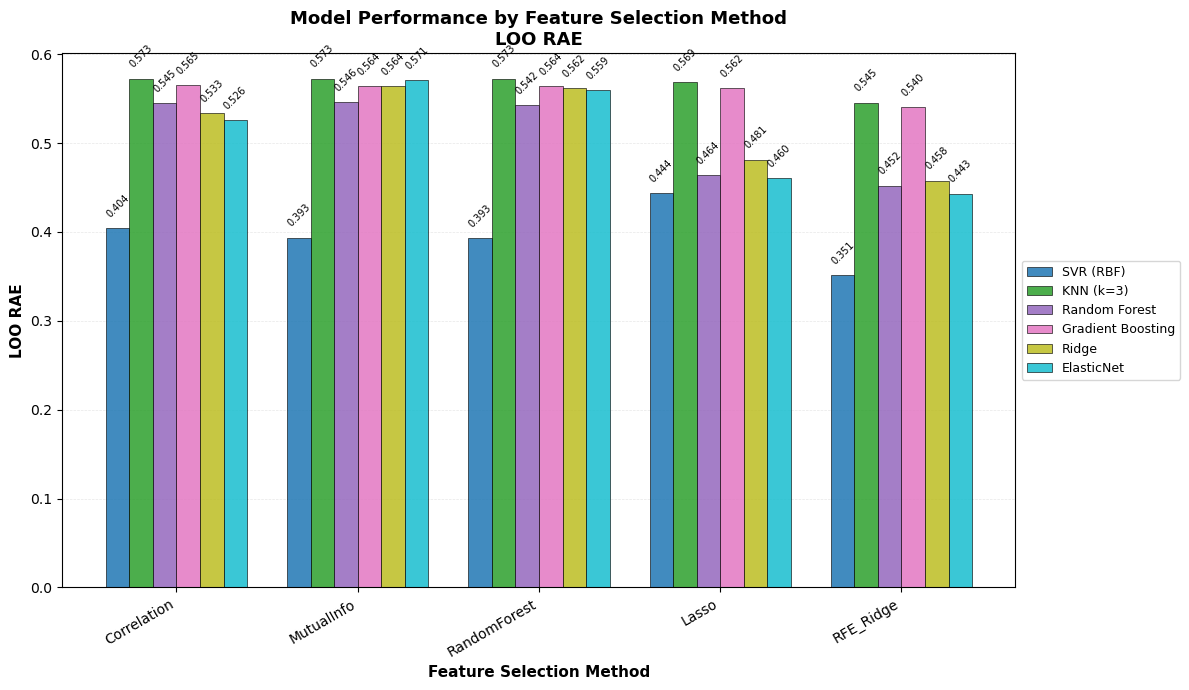

In [104]:
plot_model_performance(results_matrix_squared, "LOO RAE")

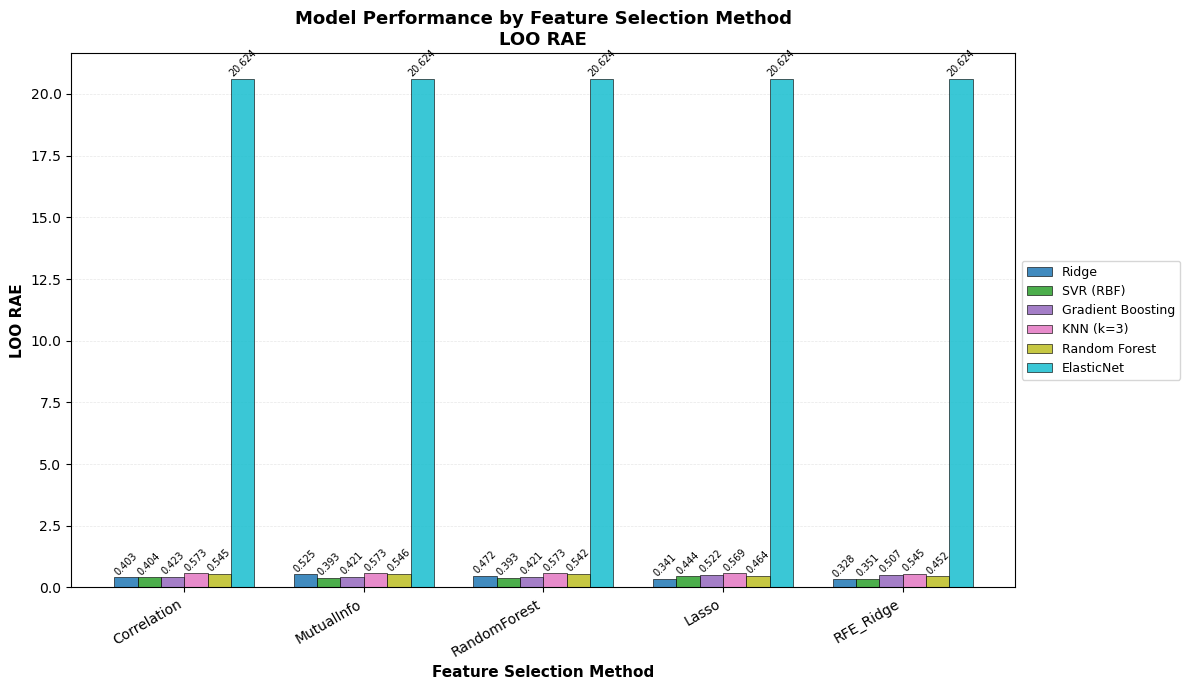

In [105]:
plot_model_performance(results_matrix_huber, "LOO RAE")

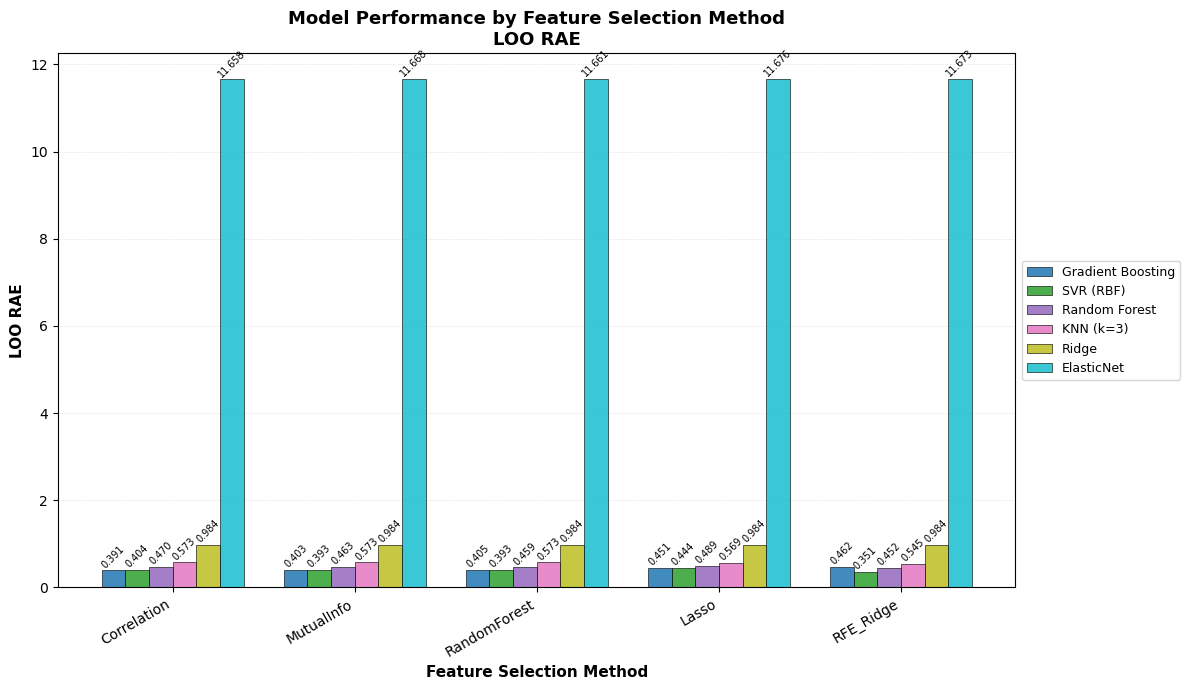

In [106]:
plot_model_performance(results_matrix_mae, "LOO RAE")

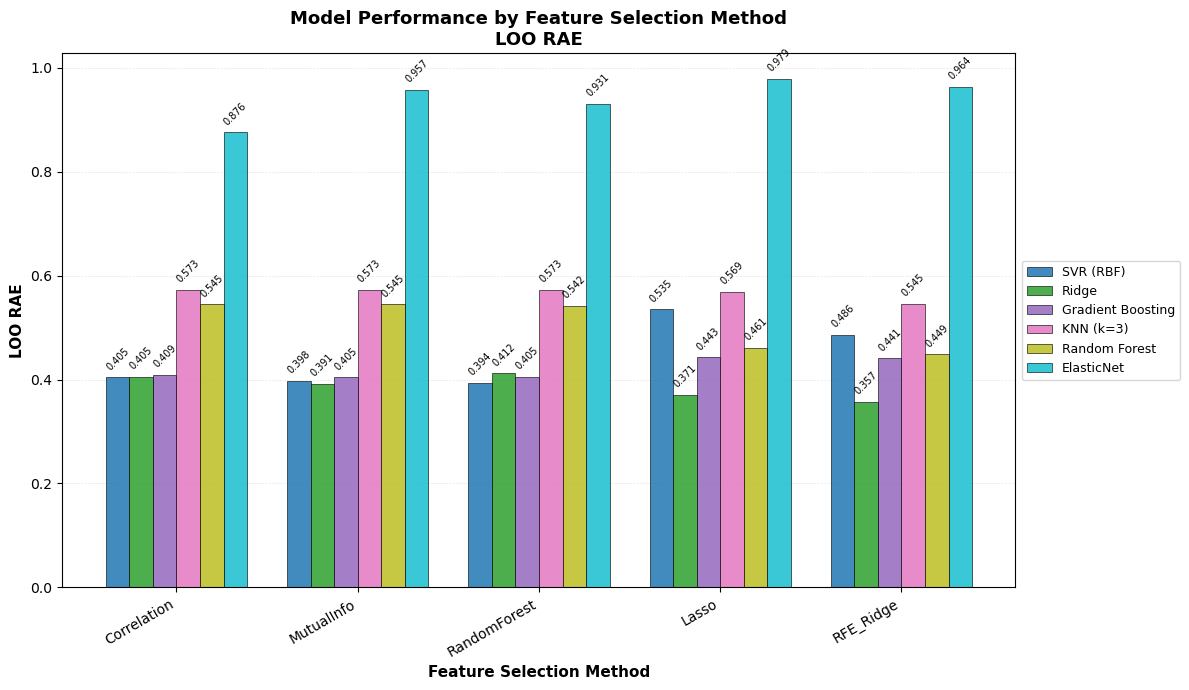

In [107]:
plot_model_performance(results_matrix_log_cosh, "LOO RAE")

In [62]:
results_matrix["Correlation"]

,Model,LOO MAE,LOO RMSE,LOO R²,KFold MAE,KFold RMSE,KFold R²
0,SVR (RBF),7.5037,16.3973,0.4882,7.6262,12.4727,0.5119
1,ElasticNet,9.7607,17.1912,0.4374,10.0484,14.3632,0.4169
2,Ridge,9.9030,17.2781,0.4318,10.1276,14.4781,0.4090
3,Random Forest,10.1209,17.9310,0.3880,10.6560,15.8258,0.2828
4,Gradient Boosting,10.4917,18.1075,0.3759,10.5929,15.8770,0.2726
5,KNN (k=3),10.6292,18.7711,0.3293,10.8121,16.2304,0.2526


In [79]:
data_time_diff = []
data_time_diff_header = ["App A", "App B", "App A Isolated Time", "App A Co-Scheduled Time with App B", "App A Time Diff"]
for i in data_df_extended.iloc:
    data_time_diff.append([i["App A"], i["App B"], i["App A Isolated Time"], i["App A Co-Scheduled Time with App B"],
                             i["App A Co-Scheduled Time with App B"] - i["App A Isolated Time"]])
data_time_diff_df = pd.DataFrame(data_time_diff)
data_time_diff_df.columns = data_time_diff_header
data_time_diff_df

,App A,App B,App A Isolated Time,App A Co-Scheduled Time with App B,App A Time Diff
0,beatnik,fiesta,397.734375,401.447545,3.713170
1,beatnik,lammps,397.734375,403.132812,5.398438
2,beatnik,minife,397.734375,407.513951,9.779576
3,beatnik,minivite,397.734375,405.080915,7.346540
4,beatnik,tricount,397.734375,446.388951,48.654576
5,fiesta,lammps,359.091518,356.097656,-2.993862
6,fiesta,minife,359.091518,356.042969,-3.048549
7,fiesta,minivite,359.091518,356.143415,-2.948103
8,fiesta,tricount,359.091518,356.861607,-2.229911
9,lammps,minife,354.750000,352.250000,-2.500000


In [81]:
data_time_diff_df["App A Time Diff"]

0      3.713170
1      5.398438
2      9.779576
3      7.346540
4     48.654576
5     -2.993862
6     -3.048549
7     -2.948103
8     -2.229911
9     -2.500000
10    -2.750000
11    74.500000
12    -0.750000
13    10.750000
14    22.000000
15    -2.946987
16     4.250000
17     2.750000
18     6.250000
19    17.000000
20     5.000000
21     0.500000
22     3.000000
23     5.000000
24    -0.250000
25     2.750000
26     9.500000
27    -0.750000
28    13.250000
29    14.500000
Name: App A Time Diff, dtype: float64